# 데이터 로드 & 확인

In [8]:
import pandas as pd

df = pd.read_csv('/home/ubuntu/projects/data/bbc-text.csv')
print(df.shape)
print(df['category'].value_counts())
df.head()

(2225, 2)
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# 전처리 - 레이블 인코딩 + 토크나이징 + 패딩

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 레이블 인코딩
le = LabelEncoder()
y = le.fit_transform(df['category'])  # sport/tech/... → 0,1,2,3,4

# 텍스트 토크나이징
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text'])
X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=200, padding='post', truncating='post')

# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)

(1780, 200) (1780,)


# 모델

## RNN

In [10]:
from tensorflow.keras import Sequential, layers

model_rnn = Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=200),
    layers.SimpleRNN(32),
    layers.Dense(5, activation='softmax')
])
model_rnn.summary()
model_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
model_rnn.evaluate(X_test, y_test)

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

I0000 00:00:1775030302.575206  123745 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_5452_grad_5607_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030302.575305  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6091__.24


22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2118 - loss: 1.6216

I0000 00:00:1775030304.521615  123744 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_5452_grad_5607_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030304.521710  123744 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6091__.24


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.2500 - loss: 1.6016 - val_accuracy: 0.3904 - val_loss: 1.5017
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3862 - loss: 1.4720 - val_accuracy: 0.2921 - val_loss: 1.6002
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7760 - loss: 1.2547 - val_accuracy: 0.2809 - val_loss: 1.6017
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.9298 - loss: 0.9439 - val_accuracy: 0.2584 - val_loss: 1.6034
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9895 - loss: 0.6230 - val_accuracy: 0.3006 - val_loss: 1.6020
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9986 - loss: 0.3718 - val_accuracy: 0.2809 - val_loss: 1.6273
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.2290 - val_accuracy: 0.3118 - val_loss: 1.6353
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 1.0000 - loss: 0.1486 - val_accuracy: 0.3034 - val_loss: 

[1.687428593635559, 0.3056179881095886]

## DNN

In [11]:
model_dnn = Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=200),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
])
model_dnn.summary()
model_dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_dnn = model_dnn.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
model_dnn.evaluate(X_test, y_test)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

I0000 00:00:1775030317.841733  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9248__.14


18/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2503 - loss: 1.5984

I0000 00:00:1775030319.430908  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9248__.14


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.3020 - loss: 1.5780 - val_accuracy: 0.4522 - val_loss: 1.5125
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8448 - loss: 1.1403 - val_accuracy: 0.7416 - val_loss: 1.0876
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9824 - loss: 0.3666 - val_accuracy: 0.8624 - val_loss: 0.5400
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9986 - loss: 0.0524 - val_accuracy: 0.8933 - val_loss: 0.3758
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0142 - val_accuracy: 0.9045 - val_loss: 0.3348
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.9129 - val_loss: 0.3136
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.9185 - val_loss: 0.3009
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9185 - val_loss: 0.2928
E

[0.36731448769569397, 0.8741573095321655]

## LSTM

In [12]:
model_lstm = Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=200),
    layers.LSTM(32),
    layers.Dense(5, activation='softmax')
])
model_lstm.summary()
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
model_lstm.evaluate(X_test, y_test)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2353 - loss: 1.5982 - val_accuracy: 0.2500 - val_loss: 1.5756
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3483 - loss: 1.5200 - val_accuracy: 0.4045 - val_loss: 1.3465
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3989 - loss: 1.3702 - val_accuracy: 0.3989 - val_loss: 1.3495
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4551 - loss: 1.3756 - val_accuracy: 0.4579 - val_loss: 1.3364
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5042 - loss: 1.1390 - val_accuracy: 0.5843 - val_loss: 1.0790
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4965 - loss: 1.0680 - val_accuracy: 0.5478 - val_loss: 1.0541
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5449 - loss: 1.0131 - val_accuracy: 0.5337 - val_loss: 1.0557
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6081 - loss: 0.8319 - val_accuracy: 0.6096 - v

[1.3125182390213013, 0.40674155950546265]

In [13]:
import pandas as pd

names    = ['SimpleRNN', 'DNN', 'LSTM']
models   = [model_rnn,    model_dnn,    model_lstm]
histories = [history_rnn, history_dnn, history_lstm]

results = []
for name, model, hist in zip(names, models, histories):
    tr  = round(hist.history['accuracy'][-1]*100, 1)
    val = round(hist.history['val_accuracy'][-1]*100, 1)
    _, te = model.evaluate(X_test, y_test, verbose=0)
    results.append([name, tr, val, round(te*100, 1)])

df = pd.DataFrame(results, columns=['모델', 'Train Acc(%)', 'Val Acc(%)', 'Test Acc(%)'])
df

,모델,Train Acc(%),Val Acc(%),Test Acc(%)
0,SimpleRNN,100.0,31.5,30.6
1,DNN,100.0,91.9,87.4
2,LSTM,56.3,44.7,40.7


# RNN/DNN 과적합

In [14]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

def run_exp(model, X_tr, y_tr, X_te, y_te, epochs=10, callbacks=None):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(X_tr, y_tr, epochs=epochs, batch_size=64, 
                     validation_split=0.2, callbacks=callbacks, verbose=0)
    _, te = model.evaluate(X_te, y_te, verbose=0)
    tr  = round(hist.history['accuracy'][-1]*100, 1)
    val = round(hist.history['val_accuracy'][-1]*100, 1)
    return tr, val, round(te*100, 1)

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
results = []

## RNN 실험

In [15]:
# 기본
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.SimpleRNN(32), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test)
results.append(['RNN', '기본', tr, val, te])

# ① Dropout
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.SimpleRNN(32), layers.Dropout(0.3), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test)
results.append(['RNN', '① Dropout(0.3)', tr, val, te])

# ② epochs=5
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.SimpleRNN(32), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, epochs=5)
results.append(['RNN', '② epochs=5', tr, val, te])

# ③ EarlyStopping
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.SimpleRNN(32), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, callbacks=[es])
results.append(['RNN', '③ EarlyStopping', tr, val, te])

# ④ Dropout + EarlyStopping
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.SimpleRNN(32), layers.Dropout(0.3), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, callbacks=[es])
results.append(['RNN', '④ Dropout+ES', tr, val, te])

print("RNN 완료")

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775030332.424645  123742 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_2_1_while_body_16633_grad_16788_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030332.424741  123742 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17272__.24
I0000 00:00:1775030334.233449  123740 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_2_1_while_body_16633_grad_16788_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030334.233535  123740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17272__.24
I0000 00:00:1775030349.846964  123745 dot_merger.cc:481] Merging Dots in computation: sequential_5_1_simple_rnn_3_1_while_body_20663_grad_20859_const_0__.22.clo

RNN 완료


## DNN 실험

In [16]:
# 기본
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.Flatten(), layers.Dense(64,activation='relu'), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test)
results.append(['DNN', '기본', tr, val, te])

# ① Dropout
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.Flatten(), layers.Dense(64,activation='relu'), layers.Dropout(0.3), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test)
results.append(['DNN', '① Dropout(0.3)', tr, val, te])

# ② epochs=5
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.Flatten(), layers.Dense(64,activation='relu'), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, epochs=5)
results.append(['DNN', '② epochs=5', tr, val, te])

# ③ EarlyStopping
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.Flatten(), layers.Dense(64,activation='relu'), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, callbacks=[es])
results.append(['DNN', '③ EarlyStopping', tr, val, te])

# ④ Dropout + EarlyStopping
m = Sequential([layers.Embedding(10000,32,input_length=200), layers.Flatten(), layers.Dense(64,activation='relu'), layers.Dropout(0.3), layers.Dense(5,activation='softmax')])
tr,val,te = run_exp(m, X_train, y_train, X_test, y_test, callbacks=[es])
results.append(['DNN', '④ Dropout+ES', tr, val, te])

print("DNN 완료")

I0000 00:00:1775030398.733960  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35009__.14
I0000 00:00:1775030399.354314  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35009__.14
I0000 00:00:1775030402.809854  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38147__.15
I0000 00:00:1775030403.850200  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38147__.15
I0000 00:00:1775030407.719019  123742 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_41201__.14
I0000 00:00:1775030408.415037  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_41201__.14
I0000 00:00:1775030413.218453  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_43553__.14
I0000 00:00:1775030413.871450  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_435

DNN 완료


In [17]:
df = pd.DataFrame(results, columns=['모델', '구분', 'Train Acc(%)', 'Val Acc(%)', 'Test Acc(%)'])
base = {'RNN': results[0][4], 'DNN': results[5][4]}  # 각 모델 기본 Test Acc
df['기본 대비 차이'] = df.apply(lambda r: f"{r['Test Acc(%)'] - base[r['모델']]:+.1f}", axis=1)
df

,모델,구분,Train Acc(%),Val Acc(%),Test Acc(%),기본 대비 차이
0,RNN,기본,99.9,46.1,39.1,+0.0
1,RNN,① Dropout(0.3),99.9,25.8,31.2,-7.9
2,RNN,② epochs=5,99.4,27.0,27.4,-11.7
3,RNN,③ EarlyStopping,100.0,53.9,51.0,+11.9
4,RNN,④ Dropout+ES,70.2,26.4,25.8,-13.3
5,DNN,기본,100.0,91.9,87.4,+0.0
6,DNN,① Dropout(0.3),100.0,93.0,89.9,+2.5
7,DNN,② epochs=5,100.0,90.2,88.5,+1.1
8,DNN,③ EarlyStopping,100.0,92.1,89.7,+2.3
9,DNN,④ Dropout+ES,93.0,78.7,37.3,-50.1


# 과적합 RNN 개선 시도

In [18]:
model_rnn2 = Sequential([
    layers.Embedding(input_dim=10000, output_dim=16, input_length=200),
    layers.SpatialDropout1D(0.2),  
    layers.SimpleRNN(32, dropout=0.2, recurrent_dropout=0.2),  # RNN 내부 dropout 추가
    layers.Dense(5, activation='softmax')  # Dropout 제거
])
model_rnn2.summary()
model_rnn2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rnn2 = model_rnn2.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
model_rnn2.evaluate(X_test, y_test)

/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

I0000 00:00:1775030421.707491  123743 dot_merger.cc:481] Merging Dots in computation: sequential_14_1_simple_rnn_7_1_while_body_49378_grad_49543_const_0__.21.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030421.707593  123743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50118__.26
I0000 00:00:1775030421.759453  123743 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


21/23 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2070 - loss: 1.7117

I0000 00:00:1775030424.710786  123745 dot_merger.cc:481] Merging Dots in computation: sequential_14_1_simple_rnn_7_1_while_body_49378_grad_49543_const_0__.21.clone.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1775030424.710891  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50118__.26


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.2065 - loss: 1.7152 - val_accuracy: 0.1573 - val_loss: 1.6521
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2114 - loss: 1.7211 - val_accuracy: 0.1938 - val_loss: 1.6704
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2029 - loss: 1.6919 - val_accuracy: 0.2388 - val_loss: 1.6259
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2184 - loss: 1.6553 - val_accuracy: 0.2219 - val_loss: 1.6273
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2282 - loss: 1.6557 - val_accuracy: 0.2275 - val_loss: 1.6144
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2233 - loss: 1.6366 - val_accuracy: 0.2500 - val_loss: 1.5970
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2156 - loss: 1.6381 - val_accuracy: 0.2275 - val_loss: 1.6026
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2275 - loss: 1.6263 - val_accuracy: 0.2275 - val_loss: 1

[1.5742443799972534, 0.25168538093566895]

## 기존 모델과 비교

In [19]:
models = {
    'RNN 기본'        : (model_rnn,  history_rnn),
    'RNN SpatialDrop' : (model_rnn2, history_rnn2),
}

for name, (model, hist) in models.items():
    tr  = round(hist.history['accuracy'][-1]*100, 1)
    val = round(hist.history['val_accuracy'][-1]*100, 1)
    _, te = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:20s}  Train:{tr}  Val:{val}  Test:{round(te*100,1)}")

RNN 기본                Train:100.0  Val:31.5  Test:30.6
RNN SpatialDrop       Train:22.6  Val:25.0  Test:25.2


In [20]:
# 결론: RNN 포기!! SimpleRNN은 긴 텍스트(200 단어) 에서 장기 의존성 문제로 근본적으로 취약... 드롭아웃을 조금만 줘도 학습 자체가 안 됨 ㅜㅜ 

# 과적합 DNN 개선 시도

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_dnn3 = Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=200),
    layers.SpatialDropout1D(0.2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])
model_dnn3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_dnn3 = model_dnn3.fit(X_train, y_train, epochs=30, batch_size=64, 
                               validation_split=0.2, callbacks=[es])
model_dnn3.evaluate(X_test, y_test)

Epoch 1/30


I0000 00:00:1775030437.969951  123742 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_53766__.16


15/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2307 - loss: 1.6050

I0000 00:00:1775030439.539183  123745 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_53766__.16


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.2816 - loss: 1.5891 - val_accuracy: 0.3624 - val_loss: 1.5501
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6945 - loss: 1.3296 - val_accuracy: 0.4860 - val_loss: 1.3626
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9164 - loss: 0.7716 - val_accuracy: 0.7837 - val_loss: 0.8863
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9909 - loss: 0.2507 - val_accuracy: 0.8792 - val_loss: 0.5458
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9979 - loss: 0.0808 - val_accuracy: 0.8736 - val_loss: 0.4357
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0415 - val_accuracy: 0.9045 - val_loss: 0.3602
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0249 - val_accuracy: 0.8961 - val_loss: 0.3435
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0190 - val_accuracy: 0.9045 - val_loss: 0.3185
Ep

[0.35832980275154114, 0.8719100952148438]

## 기존 모델과 비교 

In [23]:
names     = ['DNN 기본', 'DNN 수정']
models    = [model_dnn,   model_dnn3]
histories = [history_dnn, history_dnn3]

results = []
for name, model, hist in zip(names, models, histories):
    tr  = round(hist.history['accuracy'][-1]*100, 1)
    val = round(hist.history['val_accuracy'][-1]*100, 1)
    _, te = model.evaluate(X_test, y_test, verbose=0)
    results.append([name, tr, val, round(te*100, 1)])

df = pd.DataFrame(results, columns=['모델', 'Train Acc(%)', 'Val Acc(%)', 'Test Acc(%)'])
df

,모델,Train Acc(%),Val Acc(%),Test Acc(%)
0,DNN 기본,100.0,91.9,87.4
1,DNN 수정,99.9,91.9,87.2


# LSTM 개선 시도

In [24]:
model_lstm3 = Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=200),
    layers.SpatialDropout1D(0.1),
    layers.LSTM(32, dropout=0.1, recurrent_dropout=0.1),
    layers.Dense(5, activation='softmax')
])
model_lstm3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_lstm3 = model_lstm3.fit(X_train, y_train, epochs=10, batch_size=64, 
                                 validation_split=0.2)  # callbacks 제거
model_lstm3.evaluate(X_test, y_test)

Epoch 1/10


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 786ms/step - accuracy: 0.2500 - loss: 1.6017 - val_accuracy: 0.2697 - val_loss: 1.5831
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 706ms/step - accuracy: 0.3680 - loss: 1.5344 - val_accuracy: 0.4326 - val_loss: 1.3134
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 763ms/step - accuracy: 0.4312 - loss: 1.2921 - val_accuracy: 0.4522 - val_loss: 1.2186
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 697ms/step - accuracy: 0.4544 - loss: 1.2463 - val_accuracy: 0.4579 - val_loss: 1.1852
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 778ms/step - accuracy: 0.4817 - loss: 1.1486 - val_accuracy: 0.4663 - val_loss: 1.1149
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 701ms/step - accuracy: 0.4768 - loss: 1.0963 - val_accuracy: 0.4607 - val_loss: 1.0718
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 812ms/step - accuracy: 0.5281 - loss: 1.0414 - val_accuracy: 0.4691 - val_loss: 1.0938
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 712ms/step - accuracy: 0.6306 - loss: 1.0146 - val_accuracy: 0.609

[0.8618393540382385, 0.5910112261772156]

## 기존 모델과 비교

In [25]:
names     = ['LSTM 기본', 'LSTM 수정']
models    = [model_lstm,   model_lstm3]
histories = [history_lstm, history_lstm3]

results = []
for name, model, hist in zip(names, models, histories):
    tr  = round(hist.history['accuracy'][-1]*100, 1)
    val = round(hist.history['val_accuracy'][-1]*100, 1)
    _, te = model.evaluate(X_test, y_test, verbose=0)
    results.append([name, tr, val, round(te*100, 1)])

df = pd.DataFrame(results, columns=['모델', 'Train Acc(%)', 'Val Acc(%)', 'Test Acc(%)'])
df

,모델,Train Acc(%),Val Acc(%),Test Acc(%)
0,LSTM 기본,56.3,44.7,40.7
1,LSTM 수정,67.8,62.4,59.1


# 새 문장 예측
 모델한테 새 뉴스 기사를 보여주고 어떤 카테고리인지 맞춰보라는 것

In [28]:
df_bbc = pd.read_csv('/home/ubuntu/projects/data/bbc-text.csv')
print(df_bbc['category'].value_counts())

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [38]:
# X_test에서 실제 샘플로 예측 (가장 정확함)
sample_idx = list(range(0, 50, 10))
preds = model_dnn3.predict(X_test[sample_idx])

for idx, pred in zip(sample_idx, preds):
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([pred.argmax()])[0]
    correct = "✅" if true_label == pred_label else "❌"
    print(f"{correct} 실제: {true_label:15s} | 예측: {pred_label:15s}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
✅ 실제: politics        | 예측: politics       
✅ 실제: entertainment   | 예측: entertainment  
❌ 실제: entertainment   | 예측: business       
✅ 실제: politics        | 예측: politics       
✅ 실제: business        | 예측: business       


In [39]:
# 실제 BBC 뉴스 기사로 예측
news = [
    "As the war in the Middle East enters its second month, choking the world's energy supply and sending oil prices soaring, China is trying to step in as a peacemaker. It comes as President Donald Trump says US military action in Iran could end in two to three weeks, but there is no clear sense yet of how that will happen or what comes after. China joins Pakistan, which has emerged as an unlikely mediator in the US-Israel war against Iran. Officials in Beijing and Islamabad have presented a five-point plan with the aim of bringing about a ceasefire and re-opening the vital Strait of Hormuz."
]

seq = tokenizer.texts_to_sequences(news)
pad = pad_sequences(seq, maxlen=200, padding='post', truncating='post')
pred = model_dnn3.predict(pad)

label = le.inverse_transform([pred.argmax()])[0]
prob = pred.max() * 100
print(f"예측 카테고리: {label} ({prob:.1f}%)")
for cat, p in zip(le.classes_, pred[0]):
    print(f"  {cat:15s}: {p*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
예측 카테고리: sport (85.2%)
  business       : 12.1%
  entertainment  : 0.2%
  politics       : 2.4%
  sport          : 85.2%
  tech           : 0.0%


In [ ]:
# 2004~2005년 BBC 정치 기사 문체
print(df_bbc[df_bbc['category']=='politics']['text'].iloc[0][:300])

howard hits back at mongrel jibe michael howard has said a claim by peter hain that the tory leader is acting like an  attack mongrel  shows labour is  rattled  by the opposition.  in an upbeat speech to his party s spring conference in brighton  he said labour s campaigning tactics proved the torie


## 결론
BBC 뉴스 데이터 내에서는 90% 정확도로 분류 가능하지만, 데이터 수가 적어 새로운 문장에 대한 일반화는 어렵다...ㅜㅜ

# Confusion Matrix
어떤 카테고리를 잘 맞추는지 시각화

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


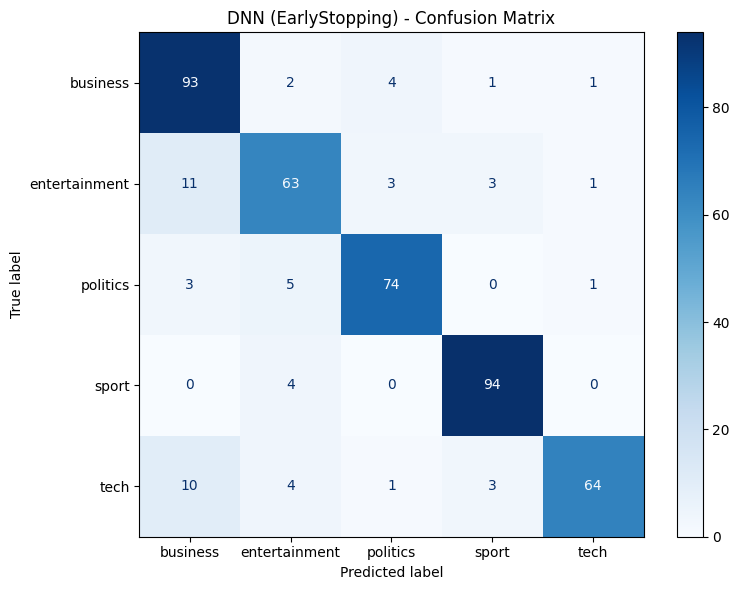

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 예측
preds = model_dnn3.predict(X_test)
y_pred = preds.argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('DNN (EarlyStopping) - Confusion Matrix')
plt.tight_layout()
plt.show()

테스트셋 기준 90.6%의 정확도를 달성하였으나, 실제 새로운 뉴스 기사 예측 시 성능이 저하되었다. 이는 학습 데이터 부족(2,225개) 및 데이터의 시대적 한계(2004~2005년)로 인해 모델의 일반화 성능이 제한되었기 때문이다. 